# Vehicle Fuel Efficiency Prediction - Final Notebook
Integration notebook. Reusable code lives in `src/vehicle_efficiency/`; this notebook calls it and explains the results.

| Section | Owner | Status |
|---|---|---|
| 1. Problem | Aktore | draft below - review |
| 2. Dataset | Aktore | draft below - review |
| 3. EDA | Aktore | TODO (copy final plots from `01_eda.ipynb`) |
| 4. Cleaning | Khamza | written from real output - awaiting teammate review |
| 5. Feature engineering | Khamza | validated on validation set + CV - awaiting teammate review |
| 6. Splitting | Khamza | executable |
| 7. Baseline | Khamza | written - awaiting teammate review |
| 8. Models | Khamza (LR: written), Askhat (Tree, KNN: TODO) | partly done |
| 9. Evaluation | Askhat | TODO |
| 10. Conclusions | all | TODO |
| 11. Final-stage plan | Aktore | TODO |

Only mark a section done when it has been reviewed by a teammate.

In [1]:
import pandas as pd
from vehicle_efficiency.data import download_raw, load_dataset, load_raw, make_splits, prepare
from vehicle_efficiency.evaluation import cross_validate_pipeline, evaluate
from vehicle_efficiency.models import (build_baseline, build_decision_tree,
                                       build_knn, build_linear_regression)
from vehicle_efficiency.preprocessing import add_features, missing_summary, split_xy

results = {}  # model name -> validation metrics, filled in below

## 1. Problem
Predict a vehicle's fuel efficiency (**MPG**, EPA combined miles per gallon; higher = more efficient) from attributes such as cylinders, engine displacement, model year, drive and transmission. Weight and horsepower are not available in this dataset (see `data/README.md`). This is a **regression** problem.

**Prediction scenario:** estimating the combined MPG of a recent (model year 2015+) gasoline, diesel, hybrid or flex-fuel vehicle from its specification. TODO (Aktore): refine the problem statement in your own words.

**Metrics:** MAE (primary, in MPG: average absolute error), RMSE (in MPG: penalises large errors more), R² (unitless: share of variance explained relative to predicting the mean).

## 2. Dataset
US EPA / DOE *fueleconomy.gov* vehicle data (`vehicles.csv`), restricted to model years 2015 and later. Details, scope filter, limitations and licence notes: `data/README.md`. TODO (Aktore): add your own dataset discussion.

In [2]:
download_raw()          # no-op if already downloaded
raw = load_dataset()    # scope filter (2015+, no EV/PHEV/FCV) + schema check
print(raw.shape)
raw.head()

(13975, 14)


,row_id,model_year,make,model,mpg,cylinders,displacement,drive,vehicle_class,fuel_type,transmission,hybrid,turbo,supercharged
0,27058,2015,Nissan,GT-R,19,6.0,3.8,All-Wheel Drive,Subcompact Cars,Premium Gasoline,Automatic,0,1,0
1,27059,2015,Volvo,S60 AWD,23,5.0,2.5,All-Wheel Drive,Compact Cars,Regular Gasoline,Automatic,0,1,0
2,27060,2015,Mazda,6,30,4.0,2.5,Front-Wheel Drive,Midsize Cars,Regular Gasoline,Automatic,0,0,0
3,27061,2015,Mazda,6,32,4.0,2.5,Front-Wheel Drive,Midsize Cars,Regular Gasoline,Automatic,0,0,0
4,27062,2015,Mazda,6,29,4.0,2.5,Front-Wheel Drive,Midsize Cars,Regular Gasoline,Manual,0,0,0


## 3. EDA
**Status: TODO (Aktore)** - bring the four+ final plots and interpretations from `01_eda.ipynb` here (or embed the saved figures from `reports/figures/`). EDA must use the training split only.

## 4. Cleaning
Owner: Khamza. The scope filter and flag derivation are stateless and run before splitting (`data.prepare`). Remaining missing values would be *imputed inside the pipeline* (fitted on training rows only), so no further rows are dropped and nothing leaks.

In [3]:
raw_all = load_raw()
in_years = raw_all[raw_all["model_year"] >= 2015]
print(f"raw rows: {len(raw_all)} | model year >= 2015: {len(in_years)} | kept after scope filter: {len(raw)}")
print("removed as MPGe/CNG vehicles (atv_type):")
print(in_years[~in_years["row_id"].isin(raw["row_id"])]["atv_type"].value_counts())
print(f"rows that are exact duplicates of another row: {raw.duplicated(subset=[c for c in raw.columns if c != 'row_id']).sum()}")

raw rows: 50407 | model year >= 2015: 15994 | kept after scope filter: 13975
removed as MPGe/CNG vehicles (atv_type):


atv_type
EV                1544
Plug-in Hybrid     429
FCV                 41
Bifuel (CNG)         2
eFCV                 2
CNG                  1
Name: count, dtype: int64
rows that are exact duplicates of another row: 416


In [4]:
splits = make_splits(raw)
train, val, test = splits["train"], splits["val"], splits["test"]
print("Missing values in the training split (used columns):")
print(missing_summary(train).query("missing > 0") if missing_summary(train)["missing"].any() else "none")
train.describe().T[["min", "mean", "max"]]

Missing values in the training split (used columns):
none


,min,mean,max
row_id,27059.0,35460.434087,44909.0
model_year,2015.0,2020.301752,2027.0
mpg,9.0,23.207518,59.0
cylinders,3.0,5.566830,16.0
displacement,0.9,3.112826,8.4
hybrid,0.0,0.109617,1.0
turbo,0.0,0.549205,1.0
supercharged,0.0,0.046047,1.0


**Cleaning decisions and findings** (from the run on 2026-10-07, seed 42; rerun the cells to refresh):
- Of 50,407 raw rows, 15,994 are model year 2015 or later. 2,019 of those were removed because they are EV (1,544), plug-in hybrid (429), fuel-cell (43) or CNG (3) vehicles, whose efficiency is reported in MPGe, not MPG. **13,975 rows remain.**
- **No missing values** remain in the used columns, so the imputers in the pipeline are a safeguard (and are fitted on training data only if a gap ever appears in new data).
- `make`/`model` are not features (too many distinct values); `trany` is reduced to `transmission` (Automatic/Manual/Other).
- 416 rows are exact duplicates of another row; they are kept together in one split.
- **Plausibility check on the training split:** MPG 9-59, displacement 0.9-8.4 L, cylinders 3-16 (3, 4, 5, 6, 8, 10, 12, 16), all positive and consistent with real road vehicles. We found nothing to remove. Extreme values (16 cylinders, 59 MPG hybrids) are real cars, so they stay.

## 5. Feature engineering
Owner: Khamza. One stateless engineered feature, `displacement_per_cylinder` (litres per cylinder): engine size per cylinder should separate large-bore engines from small turbo engines better than either column alone. Categorical columns (`drive`, `transmission`, `vehicle_class`, `fuel_type`) are one-hot encoded.

We test the hypothesis with Linear Regression on **validation** data and with 5-fold CV on **training** data only (the test set is untouched).

In [5]:
add_features(split_xy(train)[0]).head()

,model_year,cylinders,displacement,hybrid,turbo,supercharged,drive,transmission,vehicle_class,fuel_type,displacement_per_cylinder
1,2015,5.0,2.5,0,1,0,All-Wheel Drive,Automatic,Compact Cars,Regular Gasoline,0.500000
2,2015,4.0,2.5,0,0,0,Front-Wheel Drive,Automatic,Midsize Cars,Regular Gasoline,0.625000
4,2015,4.0,2.5,0,0,0,Front-Wheel Drive,Manual,Midsize Cars,Regular Gasoline,0.625000
5,2015,6.0,3.8,0,0,0,Rear-Wheel Drive,Automatic,Large Cars,Regular Gasoline,0.633333
6,2015,8.0,5.0,0,0,0,Rear-Wheel Drive,Automatic,Large Cars,Premium Gasoline,0.625000


In [6]:
X_tr, y_tr = split_xy(train)
X_va, y_va = split_xy(val)
rows = {}
for label, kwargs in {"LR (base features)": {}, "LR + displacement_per_cylinder": {"engineered": True}}.items():
    p = build_linear_regression(**kwargs).fit(X_tr, y_tr)
    cv = cross_validate_pipeline(p, X_tr, y_tr)
    rows[label] = {**{f"val_{k}": v for k, v in evaluate(p, X_va, y_va).items()},
                   "cv_mae_mean": cv["mae_mean"], "cv_mae_std": cv["mae_std"]}
pd.DataFrame(rows).T.round(3)

,val_mae,val_rmse,val_r2,cv_mae_mean,cv_mae_std
LR (base features),2.132,2.873,0.785,2.086,0.015
LR + displacement_per_cylinder,2.019,2.778,0.799,1.987,0.007


**Outcome** (run of 2026-10-07, seed 42): adding `displacement_per_cylinder` lowered validation MAE from 2.13 to 2.02 MPG (RMSE 2.87 to 2.78, R² 0.785 to 0.799). Training-only 5-fold CV agrees: MAE 2.09 ± 0.015 vs 1.99 ± 0.007 MPG, and the improvement is far larger than the fold-to-fold spread. **Decision: keep the feature** (`engineered=True`). Caveat: this is one split of one dataset; the gain is about 0.1 MPG.

## 6. Splitting
70% train / 15% validation / 15% test, `random_state=42`, random split of records. Exact duplicate rows are grouped so they cannot cross splits. Note: near-identical variants of one car model can still land in different splits (see limitations in `data/README.md`). Train for fitting and EDA, validation for model selection, test only once at the end.

In [7]:
print({k: len(v) for k, v in splits.items()})
ids = {k: set(v["row_id"]) for k, v in splits.items()}
assert not (ids["train"] & ids["val"] or ids["train"] & ids["test"] or ids["val"] & ids["test"])
X_train, y_train = split_xy(train)
X_val, y_val = split_xy(val)
X_test, y_test = split_xy(test)  # not used until section 9

{'train': 9816, 'val': 2080, 'test': 2079}


## 7. Baseline - DummyRegressor (predicts the training mean MPG)
Any real model has to beat this.

In [8]:
baseline = build_baseline().fit(X_train, y_train)
results["Baseline (mean)"] = evaluate(baseline, X_val, y_val)
pd.DataFrame(results).T.rename(columns={"mae": "MAE (MPG)", "rmse": "RMSE (MPG)", "r2": "R2"})

,MAE (MPG),RMSE (MPG),R2
Baseline (mean),4.66176,6.196671,-1.294925e-07


**Interpretation:** the baseline always predicts the training mean MPG (about 23.2). On validation it is off by 4.66 MPG on average (MAE) with R² ≈ 0, as expected for a model that ignores every feature. Any real model must beat MAE 4.66 MPG; the spread of MPG in this data (std about 6.2) is the size of the problem.

## 8. Models

### Linear Regression
**Owner: Khamza** | Status: **DONE - awaiting teammate review**

Scaled numeric features + one-hot categoricals, with the engineered feature chosen in section 5. Ridge (alpha=1) was also tried as a check.

In [9]:
lr = build_linear_regression(engineered=True).fit(X_train, y_train)
results["Linear Regression"] = evaluate(lr, X_val, y_val)
ridge = build_linear_regression(engineered=True, alpha=1.0).fit(X_train, y_train)
print("Ridge(alpha=1) validation:", {k: round(v, 3) for k, v in evaluate(ridge, X_val, y_val).items()})
lr_cv = cross_validate_pipeline(lr, X_train, y_train)
print(f"LR 5-fold CV on train: MAE {lr_cv['mae_mean']:.3f} +/- {lr_cv['mae_std']:.3f} MPG")
print("train:", {k: round(v, 3) for k, v in evaluate(lr, X_train, y_train).items()})
pd.DataFrame(results).T.rename(columns={"mae": "MAE (MPG)", "rmse": "RMSE (MPG)", "r2": "R2"}).round(3)

Ridge(alpha=1) validation: {'mae': 2.021, 'rmse': 2.778, 'r2': 0.799}


LR 5-fold CV on train: MAE 1.987 +/- 0.007 MPG
train: {'mae': 1.977, 'rmse': 2.775, 'r2': 0.802}


,MAE (MPG),RMSE (MPG),R2
Baseline (mean),4.662,6.197,-0.000
Linear Regression,2.019,2.778,0.799


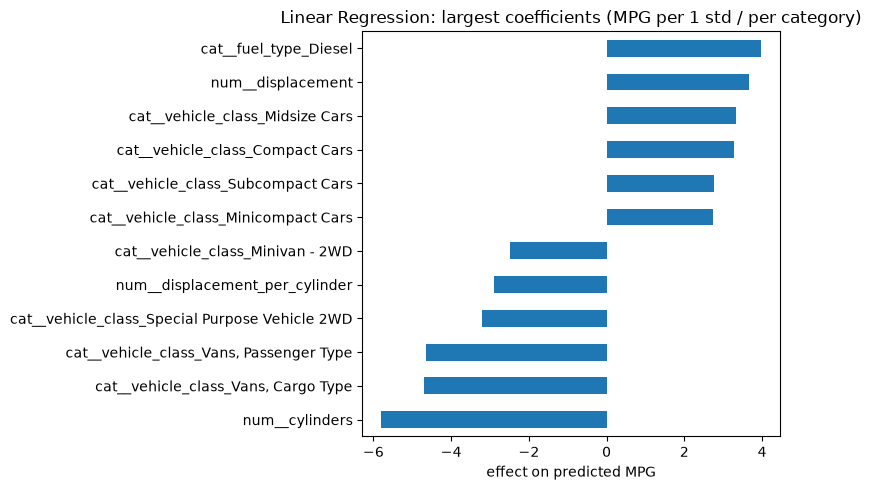

validation residual mean: -0.048 | largest absolute error: 18.2 MPG


In [10]:
import matplotlib.pyplot as plt
names = lr.named_steps["prep"].get_feature_names_out()
coef = pd.Series(lr.named_steps["model"].coef_, index=names).sort_values()
show = pd.concat([coef.head(6), coef.tail(6)])
ax = show.plot.barh(figsize=(8, 5), title="Linear Regression: largest coefficients (MPG per 1 std / per category)")
ax.set_xlabel("effect on predicted MPG"); plt.tight_layout(); plt.show()
resid = y_val - lr.predict(X_val)
print("validation residual mean:", round(resid.mean(), 3), "| largest absolute error:", round(resid.abs().max(), 1), "MPG")

**Interpretation (run of 2026-10-07, seed 42):**
- Validation MAE **2.02 MPG**, RMSE 2.78 MPG, R² 0.80, versus baseline MAE 4.66 MPG: the model removes about 57% of the baseline's average error (4.66 → 2.02).
- Train MAE (1.98) and validation MAE (2.02) are close, and CV MAE is 1.99 ± 0.007, so there is no sign of overfitting; remaining error looks like **underfitting** (a linear model with no weight/horsepower), not variance.
- Ridge (alpha=1) gave the same result (2.02), so regularisation does not help here.
- **Sign sanity check:** larger displacement lowers predicted MPG, and vans/minivans/special-purpose vehicles have the most negative effects, which matches physical intuition. Diesel and compact/midsize cars raise it. Premium gasoline lowers it, probably because it marks performance cars, not because the fuel itself reduces MPG (the features are correlated, so individual coefficients should not be read as causal).
- Largest single validation error is 18.3 MPG, so some vehicles are predicted very badly; Askhat's error analysis should look at them.

### Decision Tree
**Owner: Askhat** | Status: **NOT STARTED**

Implement `build_decision_tree` in `models.py`; tune `max_depth`/`min_samples_leaf` using validation data/CV.

In [11]:
try:
    pipe = build_decision_tree()
except NotImplementedError as exc:
    print("NOT IMPLEMENTED YET:", exc)
else:
    pipe.fit(X_train, y_train)
    metrics = evaluate(pipe, X_val, y_val)
    print(metrics)
    # TODO (Askhat): store metrics in `results` for the comparison table below
    # results["Decision Tree"] = metrics

NOT IMPLEMENTED YET: Decision Tree is Askhat's task - see docs/team_tasks.md


### KNN
**Owner: Askhat** | Status: **NOT STARTED**

Implement `build_knn` in `models.py` (scaling is mandatory); tune `n_neighbors`.

In [12]:
try:
    pipe = build_knn()
except NotImplementedError as exc:
    print("NOT IMPLEMENTED YET:", exc)
else:
    pipe.fit(X_train, y_train)
    metrics = evaluate(pipe, X_val, y_val)
    print(metrics)
    # TODO (Askhat): store metrics in `results` for the comparison table below
    # results["KNN"] = metrics

NOT IMPLEMENTED YET: KNN is Askhat's task - see docs/team_tasks.md


### Cross-validation
**Owner: Askhat** | Status: **NOT STARTED**. Use `cross_validate_pipeline(pipe, X_train, y_train)` (preprocessing is refit per fold). Report mean ± std for at least one model.

In [13]:
# TODO (Askhat): cross-validation results


## 9. Evaluation
**Owner: Askhat** | Status: **NOT STARTED**. (1) Comparison table of baseline + 3 models on validation data. (2) Choose the final model from validation results. (3) Only then evaluate **once** on the test split. (4) Error analysis: residual plots, worst predictions.

In [14]:
# TODO (Askhat): comparison table, final model choice, single test evaluation, error analysis


## 10. Conclusions
**Status: NOT STARTED - all.** **Conclusions:** write only what the real results above support: best model, how much it improves on the baseline (in MPG), limitations (no weight/horsepower, only 2015+ vehicles, near-duplicate variants of the same model), what you would try next.

## 11. Final-stage plan
**Owner: Aktore** | Status: **NOT STARTED**. Summarise `docs/final_stage_plan.md` once written.